# 🎯 Milestone 2: Complete Knowledge Graph Construction

**AI Knowledge Graph Builder for Enterprise Intelligence**

---

## 📋 What This Notebook Does

**Part A: Core Graph Construction**
1. ✅ Entity Extraction (4 types: Job, Location, Department, Category)
2. ✅ Relationship Mapping (3 types: LOCATED_IN, IN_DEPARTMENT, BELONGS_TO)
3. ✅ Neo4j Graph Building
4. ✅ Graph Validation & Statistics

**Part B: LLM-Based NER Enhancement**

5. ✅ Skills Extraction using Llama 3 via Groq - FREE (NER)
6. ✅ Add 5th Entity Type (Skill nodes)
7. ✅ Add 4th Relationship Type (REQUIRES)
8. ✅ Enhanced Graph with Skills

---

✅ **Schema-based entity extraction** for structured data (Jobs, Locations, Departments, Categories)  
✅ **LLM-based Named Entity Recognition** for unstructured text (Skills extraction from job context)  
✅ **Complete knowledge graph** with 5 entity types and 4 relationship types  

---

# SECTION 1: Setup & Installation

## 1.1 Install Dependencies

In [1]:
!pip install pandas networkx matplotlib seaborn neo4j groq -q

print('✅ All dependencies installed!')
print('   • pandas, networkx, matplotlib, seaborn, neo4j')
print('   • groq (Llama 3 LLM - FREE) 🆕')

✅ All dependencies installed!
   • pandas, networkx, matplotlib, seaborn, neo4j
   • groq (Llama 3 LLM - FREE) 🆕



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\sukum\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


## 1.2 Import Libraries

In [3]:
import sys
!{sys.executable} -m pip install neo4j groq
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
import json
import time
import warnings
warnings.filterwarnings('ignore')
from neo4j import GraphDatabase
from groq import Groq  # FREE Llama 3 LLM
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
print('✅ All libraries imported successfully!')


   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   -------------------- ------------------- 1/2 [groq]
   -------------------- ------------------- 1/2 

## 1.3 Configuration

In [29]:
# CONFIGURATION

USE_NEO4J = True
USE_LLM_NER = True
import os
NEO4J_URI = os.getenv("NEO4J_URI")
NEO4J_USER = os.getenv("NEO4J_USER")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")

# FREE Groq API key - get at console.groq.com (no credit card)
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

# ════════════════════════════════════════════════════════════════
print('✅ Configuration set')
print(f'  • Neo4j: {"Enabled" if USE_NEO4J else "Disabled"}')
print(f'  • LLM NER (Llama 3): {"Enabled" if USE_LLM_NER else "Disabled"}')
if USE_LLM_NER:
    print('  • Model : llama3-8b-8192 via Groq (FREE)')
    print('  • Input : Job_Description column from dataset')
    print('  • Output: Skills_Extracted column (NER entities)')

✅ Configuration set
  • Neo4j: Enabled
  • LLM NER (Llama 3): Enabled
  • Model : llama3-8b-8192 via Groq (FREE)
  • Input : Job_Description column from dataset
  • Output: Skills_Extracted column (NER entities)


## 1.4 Upload Data from Milestone 1

In [ ]:
import pandas as pd

file_path = '../data/processed/processed_data_milestone1_with_descriptions.csv'
df = pd.read_csv(file_path)

print("✅ File loaded successfully")
print(df.shape)

✅ File loaded successfully
(644, 26)


## 1.5 Load & Inspect Data

In [7]:
# Load the data
df = pd.read_csv(file_path)

print("=" * 70)
print("  DATA LOADED SUCCESSFULLY")
print("=" * 70)
print(f"\n📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

print(f"\n✅ Data Quality:")
print(f"  • Missing values: {df.isnull().sum().sum()}")
print(f"  • Duplicate rows: {df.duplicated().sum()}")
print(f"  • Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

  DATA LOADED SUCCESSFULLY

📊 Dataset Shape: 644 rows × 26 columns

📋 Columns (26):
   1. Category
   2. Workplace
   3. Location
   4. Department
   5. Type
   6. City
   7. Region
   8. Country
   9. Workplace_Standardized
  10. Employment_Type
  11. Department_Category
  12. Category_Normalized
  13. Country_Normalized
  14. City_Normalized
  15. Job_ID
  16. Location_ID
  17. Department_ID
  18. Category_ID
  19. Priority_Class
  20. Geographic_Region
  21. Demand_Score
  22. Demand_Score_Normalized
  23. Created_At
  24. Data_Quality_Score
  25. Is_Active
  26. Job_Description

✅ Data Quality:
  • Missing values: 0
  • Duplicate rows: 0
  • Memory usage: 981.09 KB


In [8]:
# Display first few records
print("\n📋 First 5 Records:")
df.head()


📋 First 5 Records:


,Category,Workplace,Location,Department,Type,City,Region,Country,Workplace_Standardized,Employment_Type,Department_Category,Category_Normalized,Country_Normalized,City_Normalized,Job_ID,Location_ID,Department_ID,Category_ID,Priority_Class,Geographic_Region,Demand_Score,Demand_Score_Normalized,Created_At,Data_Quality_Score,Is_Active,Job_Description
0,Business Analyst,Remote,United Kingdom,Operations,Full time,Unknown,Unknown,United Kingdom,Remote,Full-Time,Operations,Business Analyst,United Kingdom,Unknown,JOB_000001,LOC_0234,DEPT_0166,CAT_000,Normal-High,Europe,14,26.92,2026-02-23 17:13:21,100,True,Analyze business processes and operational wor...
1,Business Analyst,Remote,"Makati, Metro Manila, Philippines",Aux HQ,Full time,Makati,Metro Manila,Philippines,Remote,Full-Time,Other,Business Analyst,Philippines,Makati,JOB_000002,LOC_0124,DEPT_0021,CAT_000,Normal-High,Asia Pacific,4,7.69,2026-02-23 17:13:21,100,True,Analyze business operations and support strate...
2,Business Analyst,On-site,"Al-Dajeej, Al Farwaniyah Governorate, Kuwait",PWC Technologies,Full time,Al-Dajeej,Al Farwaniyah Governorate,Kuwait,On-Site,Full-Time,Technology & Data,Business Analyst,Kuwait,Al-Dajeej,JOB_000003,LOC_0002,DEPT_0173,CAT_000,Normal,Middle East & Africa,2,3.85,2026-02-23 17:13:21,100,True,Bridge the gap between business needs and tech...
3,Business Analyst,On-site,"London, England, United Kingdom","Consultants, Advisory",Full time,London,England,United Kingdom,On-Site,Full-Time,Consulting & Advisory,Business Analyst,United Kingdom,London,JOB_000004,LOC_0117,DEPT_0049,CAT_000,Normal,Europe,52,100.00,2026-02-23 17:13:21,100,True,Provide strategic analysis and recommendations...
4,Business Analyst,Remote,"London, England, United Kingdom",Change & Innovation,Not Specified,London,England,United Kingdom,Remote,Not Specified,Other,Business Analyst,United Kingdom,London,JOB_000009,LOC_0117,DEPT_0037,CAT_000,Normal,Europe,52,100.00,2026-02-23 17:13:21,100,True,Analyze business operations and support strate...


---

# SECTION 2: Entity Extraction

## 2.1 Define Entity Types & Properties

In [9]:
# Defining the 4 core entity types for our knowledge graph
ENTITY_TYPES = {
    'Job': {
        'id_col': 'Job_ID',
        'props': ['Category_Normalized', 'Workplace_Standardized',
                  'Employment_Type', 'Priority_Class',
                  'Demand_Score_Normalized', 'Is_Active', 'Created_At']
    },
    'Location': {
        'id_col': 'Location_ID',
        'props': ['City_Normalized', 'Country_Normalized', 'Geographic_Region']
    },
    'Department': {
        'id_col': 'Department_ID',
        'props': ['Department', 'Department_Category']
    },
    'Category': {
        'id_col': 'Category_ID',
        'props': ['Category_Normalized']
    }
}

print("✅ Entity types defined:")
for entity_type, config in ENTITY_TYPES.items():
    print(f"\n  📌 {entity_type}")
    print(f"     ID Column: {config['id_col']}")
    print(f"     Properties: {', '.join(config['props'])}")

✅ Entity types defined:

  📌 Job
     ID Column: Job_ID
     Properties: Category_Normalized, Workplace_Standardized, Employment_Type, Priority_Class, Demand_Score_Normalized, Is_Active, Created_At

  📌 Location
     ID Column: Location_ID
     Properties: City_Normalized, Country_Normalized, Geographic_Region

  📌 Department
     ID Column: Department_ID
     Properties: Department, Department_Category

  📌 Category
     ID Column: Category_ID
     Properties: Category_Normalized


## 2.2 Extract All Entities

In [10]:
print("=" * 70)
print("  ENTITY EXTRACTION (Schema-Based)")
print("=" * 70)

all_entities = []

for entity_type, config in ENTITY_TYPES.items():
    id_col = config['id_col']
    props = config['props']

    # Get unique entities
    entity_cols = [id_col] + props
    entities = df[entity_cols].drop_duplicates(subset=[id_col]).copy()

    # Add entity type column
    entities['entity_type'] = entity_type

    all_entities.append(entities)
    print(f"  {entity_type:<12} → {len(entities):>4} unique entities")

# Combine all entities into one DataFrame
entities_df = pd.concat(all_entities, ignore_index=True)

print(f"\n✅ Total entities extracted: {len(entities_df)}")
print(f"   • 4 entity types (schema-based extraction)")
print(f"   • Ready for graph construction")

  ENTITY EXTRACTION (Schema-Based)
  Job          →  644 unique entities
  Location     →  257 unique entities
  Department   →  266 unique entities
  Category     →    6 unique entities

✅ Total entities extracted: 1173
   • 4 entity types (schema-based extraction)
   • Ready for graph construction


---

# SECTION 3: Relationship Extraction

## 3.1 Define Relationship Types

In [11]:
# Define the 3 core relationship types
RELATIONSHIP_TYPES = [
    {
        'name': 'LOCATED_IN',
        'from_col': 'Job_ID',
        'to_col': 'Location_ID',
        'from_type': 'Job',
        'to_type': 'Location',
        'description': 'Job is located in a specific location'
    },
    {
        'name': 'IN_DEPARTMENT',
        'from_col': 'Job_ID',
        'to_col': 'Department_ID',
        'from_type': 'Job',
        'to_type': 'Department',
        'description': 'Job belongs to a specific department'
    },
    {
        'name': 'BELONGS_TO',
        'from_col': 'Job_ID',
        'to_col': 'Category_ID',
        'from_type': 'Job',
        'to_type': 'Category',
        'description': 'Job belongs to a job category'
    }
]

print("✅ Relationship types defined:")
for rel in RELATIONSHIP_TYPES:
    print(f"\n  🔗 {rel['name']}")
    print(f"     From: {rel['from_type']} ({rel['from_col']})")
    print(f"     To:   {rel['to_type']} ({rel['to_col']})")
    print(f"     Description: {rel['description']}")

✅ Relationship types defined:

  🔗 LOCATED_IN
     From: Job (Job_ID)
     To:   Location (Location_ID)
     Description: Job is located in a specific location

  🔗 IN_DEPARTMENT
     From: Job (Job_ID)
     To:   Department (Department_ID)
     Description: Job belongs to a specific department

  🔗 BELONGS_TO
     From: Job (Job_ID)
     To:   Category (Category_ID)
     Description: Job belongs to a job category


## 3.2 Extract All Relationships

In [12]:
print("=" * 70)
print("  RELATIONSHIP EXTRACTION")
print("=" * 70)

relationships = []

for rel in RELATIONSHIP_TYPES:
    # Extract relationship edges
    rel_df = df[[rel['from_col'], rel['to_col']]].copy()
    rel_df.columns = ['from_id', 'to_id']
    rel_df['relationship'] = rel['name']
    rel_df['from_type'] = rel['from_type']
    rel_df['to_type'] = rel['to_type']

    relationships.append(rel_df)
    print(f"  {rel['name']:<18} → {len(rel_df):>4} edges")

# Combine all relationships
relationships_df = pd.concat(relationships, ignore_index=True)

print(f"\n✅ Total relationships extracted: {len(relationships_df)}")
print(f"   • 3 relationship types")
print(f"   • All jobs connected to locations, departments, categories")

  RELATIONSHIP EXTRACTION
  LOCATED_IN         →  644 edges
  IN_DEPARTMENT      →  644 edges
  BELONGS_TO         →  644 edges

✅ Total relationships extracted: 1932
   • 3 relationship types
   • All jobs connected to locations, departments, categories


---

# SECTION 4: NetworkX Graph Construction

## 4.1 Build NetworkX Graph

In [19]:
print("=" * 70)
print("  BUILDING NETWORKX GRAPH")
print("=" * 70)

# Create directed graph
G = nx.DiGraph()

print("\n📦 Adding nodes...")

# Add Job nodes
job_entities = entities_df[entities_df['entity_type'] == 'Job']
for _, row in job_entities.iterrows():
    G.add_node(row['Job_ID'],
               type='Job',
               category=row['Category_Normalized'],
               workplace=row['Workplace_Standardized'],
               employment=row['Employment_Type'],
               priority=row['Priority_Class'],
               demand=row['Demand_Score_Normalized'])
print(f"  ✓ Added {len(job_entities)} Job nodes")

# Add Location nodes
loc_entities = entities_df[entities_df['entity_type'] == 'Location']
for _, row in loc_entities.iterrows():
    G.add_node(row['Location_ID'],
               type='Location',
               city=row['City_Normalized'],
               country=row['Country_Normalized'],
               region=row['Geographic_Region'])
print(f"  ✓ Added {len(loc_entities)} Location nodes")

# Add Department nodes
dept_entities = entities_df[entities_df['entity_type'] == 'Department']
for _, row in dept_entities.iterrows():
    G.add_node(row['Department_ID'],
               type='Department',
               name=row['Department'],
               category=row['Department_Category'])
print(f"  ✓ Added {len(dept_entities)} Department nodes")

# Add Category nodes
cat_entities = entities_df[entities_df['entity_type'] == 'Category']
for _, row in cat_entities.iterrows():
    G.add_node(row['Category_ID'],
               type='Category',
               name=row['Category_Normalized'])
print(f"  ✓ Added {len(cat_entities)} Category nodes")

print("\n🔗 Adding edges...")

# Add all relationships as edges
for _, row in relationships_df.iterrows():
    G.add_edge(row['from_id'], row['to_id'], rel=row['relationship'])
print(f"  ✓ Added {len(relationships_df)} edges")

print(f"\n✅ NetworkX graph constructed successfully!")
print(f"   • Nodes: {G.number_of_nodes()}")
print(f"   • Edges: {G.number_of_edges()}")

  BUILDING NETWORKX GRAPH

📦 Adding nodes...
  ✓ Added 644 Job nodes
  ✓ Added 257 Location nodes
  ✓ Added 266 Department nodes
  ✓ Added 6 Category nodes

🔗 Adding edges...
  ✓ Added 1932 edges

✅ NetworkX graph constructed successfully!
   • Nodes: 1173
   • Edges: 1932


---

# SECTION 5: Neo4j Graph Construction

In [ ]:
from dotenv import load_dotenv
import os
NEO4J_URI="your_api_key"
NEO4J_USER="your_username"
NEO4J_PASSWORD="your_password"
if USE_NEO4J:
    print("=" * 70)
    print("  BUILDING NEO4J GRAPH")
    print("=" * 70)
    

    try:
        # Connect to Neo4j
        driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
        print("\n✅ Connected to Neo4j!")

        with driver.session() as session:
            # Clear existing data
            session.run("MATCH (n) DETACH DELETE n")
            print("  ✓ Cleared existing data")

            # Create constraints
            constraints = [
                "CREATE CONSTRAINT job_id IF NOT EXISTS FOR (j:Job) REQUIRE j.id IS UNIQUE",
                "CREATE CONSTRAINT loc_id IF NOT EXISTS FOR (l:Location) REQUIRE l.id IS UNIQUE",
                "CREATE CONSTRAINT dept_id IF NOT EXISTS FOR (d:Department) REQUIRE d.id IS UNIQUE",
                "CREATE CONSTRAINT cat_id IF NOT EXISTS FOR (c:Category) REQUIRE c.id IS UNIQUE"
            ]
            for constraint in constraints:
                try:
                    session.run(constraint)
                except:
                    pass
            print("  ✓ Created constraints")

            # Create Job nodes
            print("\n📦 Creating nodes...")
            for _, job in job_entities.iterrows():
                session.run("""
                    CREATE (j:Job {
                        id: $id,
                        category: $category,
                        workplace: $workplace,
                        employment_type: $employment_type,
                        priority_class: $priority_class,
                        demand_score: $demand_score,
                        is_active: $is_active
                    })
                """,
                    id=job['Job_ID'],
                    category=job['Category_Normalized'],
                    workplace=job['Workplace_Standardized'],
                    employment_type=job['Employment_Type'],
                    priority_class=job['Priority_Class'],
                    demand_score=float(job['Demand_Score_Normalized']),
                    is_active=bool(job['Is_Active'])
                )
            print(f"  ✓ Created {len(job_entities)} Job nodes")

            # Create Location nodes
            for _, loc in loc_entities.iterrows():
                session.run("""
                    CREATE (l:Location {
                        id: $id,
                        city: $city,
                        country: $country,
                        region: $region
                    })
                """,
                    id=loc['Location_ID'],
                    city=loc['City_Normalized'],
                    country=loc['Country_Normalized'],
                    region=loc['Geographic_Region']
                )
            print(f"  ✓ Created {len(loc_entities)} Location nodes")

            # Create Department nodes
            for _, dept in dept_entities.iterrows():
                session.run("""
                    CREATE (d:Department {
                        id: $id,
                        name: $name,
                        category: $category
                    })
                """,
                    id=dept['Department_ID'],
                    name=dept['Department'],
                    category=dept['Department_Category']
                )
            print(f"  ✓ Created {len(dept_entities)} Department nodes")

            # Create Category nodes
            for _, cat in cat_entities.iterrows():
                session.run("""
                    CREATE (c:Category {
                        id: $id,
                        name: $name
                    })
                """,
                    id=cat['Category_ID'],
                    name=cat['Category_Normalized']
                )
            print(f"  ✓ Created {len(cat_entities)} Category nodes")

            # Create relationships
            print("\n🔗 Creating relationships...")

            located_rels = relationships_df[relationships_df['relationship'] == 'LOCATED_IN']
            for _, rel in located_rels.iterrows():
                session.run("""
                    MATCH (j:Job {id: $from_id})
                    MATCH (l:Location {id: $to_id})
                    CREATE (j)-[:LOCATED_IN]->(l)
                """, from_id=rel['from_id'], to_id=rel['to_id'])
            print(f"  ✓ Created {len(located_rels)} LOCATED_IN relationships")

            dept_rels = relationships_df[relationships_df['relationship'] == 'IN_DEPARTMENT']
            for _, rel in dept_rels.iterrows():
                session.run("""
                    MATCH (j:Job {id: $from_id})
                    MATCH (d:Department {id: $to_id})
                    CREATE (j)-[:IN_DEPARTMENT]->(d)
                """, from_id=rel['from_id'], to_id=rel['to_id'])
            print(f"  ✓ Created {len(dept_rels)} IN_DEPARTMENT relationships")

            cat_rels = relationships_df[relationships_df['relationship'] == 'BELONGS_TO']
            for _, rel in cat_rels.iterrows():
                session.run("""
                    MATCH (j:Job {id: $from_id})
                    MATCH (c:Category {id: $to_id})
                    CREATE (j)-[:BELONGS_TO]->(c)
                """, from_id=rel['from_id'], to_id=rel['to_id'])
            print(f"  ✓ Created {len(cat_rels)} BELONGS_TO relationships")

        print("\n✅ Neo4j graph built successfully!")
        print(f"\n📌 Access your graph:")
        print(f"   • Neo4j Browser: https://console.neo4j.io/")
        print(f"   • Login and select your database")
        print(f"   • Try query: MATCH (j:Job)-[r]->(n) RETURN j,r,n LIMIT 25")

    except Exception as e:
        print(f"\n❌ Error connecting to Neo4j: {e}")
        print("\n⚠️  Common issues:")
        print("   1. Check NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD are correct")
        print("   2. Make sure your Neo4j Aura instance is running")
        print("   3. Verify your internet connection")
        USE_NEO4J = False
else:
    print("\n⏭️  Skipping Neo4j (USE_NEO4J = False)")
    print("   Using NetworkX graph only")

  BUILDING NEO4J GRAPH

✅ Connected to Neo4j!
  ✓ Cleared existing data
  ✓ Created constraints

📦 Creating nodes...
  ✓ Created 644 Job nodes
  ✓ Created 257 Location nodes
  ✓ Created 266 Department nodes
  ✓ Created 6 Category nodes

🔗 Creating relationships...
  ✓ Created 644 LOCATED_IN relationships
  ✓ Created 644 IN_DEPARTMENT relationships
  ✓ Created 644 BELONGS_TO relationships

✅ Neo4j graph built successfully!

📌 Access your graph:
   • Neo4j Browser: https://console.neo4j.io/
   • Login and select your database
   • Try query: MATCH (j:Job)-[r]->(n) RETURN j,r,n LIMIT 25


---

# SECTION 6: Graph Statistics and Visualization

- 6.1 **Graph** **statistics**




In [31]:
print("=" * 70)
print("  GRAPH STATISTICS (Core Graph)")
print("=" * 70)

print(f"\n📊 OVERALL METRICS:")
print(f"  Total Nodes:          {G.number_of_nodes()}")
print(f"  Total Edges:          {G.number_of_edges()}")
print(f"  Graph Density:        {nx.density(G):.4f}")
print(f"  Is Connected:         {nx.is_weakly_connected(G)}")

# Node counts
node_types = {}
for node, data in G.nodes(data=True):
    ntype = data.get('type', 'Unknown')
    node_types[ntype] = node_types.get(ntype, 0) + 1

print(f"\n📌 NODES BY TYPE:")
for ntype, count in sorted(node_types.items()):
    print(f"  {ntype:<15} {count:>4}")

# Edge counts
edge_types = {}
for u, v, data in G.edges(data=True):
    etype = data.get('rel', 'Unknown')
    edge_types[etype] = edge_types.get(etype, 0) + 1

print(f"\n🔗 RELATIONSHIPS BY TYPE:")
for etype, count in sorted(edge_types.items()):
    print(f"  {etype:<18} {count:>4}")

# Hub nodes
degrees = dict(G.degree())
top_hubs = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]

print(f"\n🎯 TOP 10 HUB NODES:")
for i, (node, degree) in enumerate(top_hubs, 1):
    node_type = G.nodes[node]['type']
    print(f"  {i:2}. {node:<18} ({node_type:<10}) → {degree} connections")

  GRAPH STATISTICS (Core Graph)

📊 OVERALL METRICS:
  Total Nodes:          1173
  Total Edges:          1932
  Graph Density:        0.0014
  Is Connected:         True

📌 NODES BY TYPE:
  Category           6
  Department       266
  Job              644
  Location         257

🔗 RELATIONSHIPS BY TYPE:
  BELONGS_TO          644
  IN_DEPARTMENT       644
  LOCATED_IN          644

🎯 TOP 10 HUB NODES:
   1. CAT_002            (Category  ) → 128 connections
   2. CAT_001            (Category  ) → 115 connections
   3. CAT_000            (Category  ) → 107 connections
   4. CAT_003            (Category  ) → 106 connections
   5. CAT_004            (Category  ) → 103 connections
   6. DEPT_0257          (Department) → 87 connections
   7. CAT_005            (Category  ) → 85 connections
   8. LOC_0117           (Location  ) → 52 connections
   9. DEPT_0102          (Department) → 51 connections
  10. LOC_0235           (Location  ) → 24 connections


- Graph Visualization

---



  KNOWLEDGE GRAPH VISUALIZATION


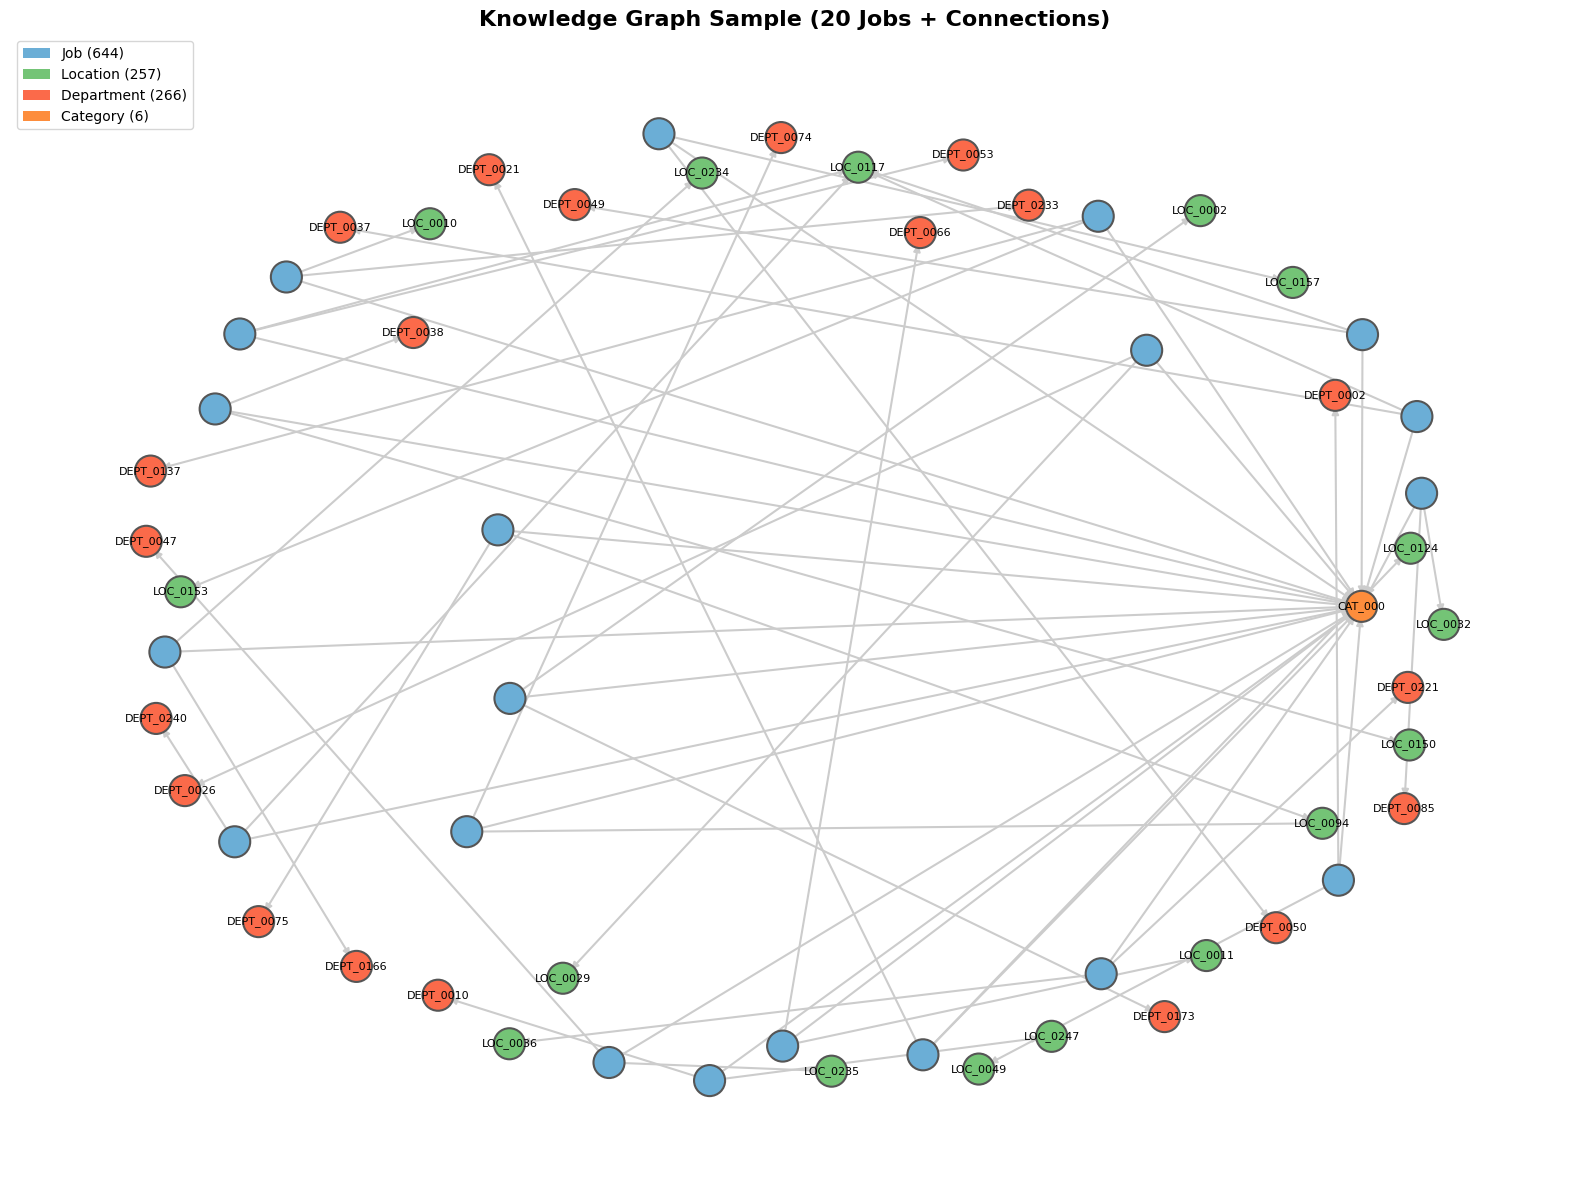


✅ Visualization saved as knowledge_graph_sample.png
   Showing: 20 Jobs + 37 connected nodes


In [32]:
# ════════════════════════════════════════════════════════════════
# KNOWLEDGE GRAPH VISUALIZATION
# ════════════════════════════════════════════════════════════════

print("=" * 70)
print("  KNOWLEDGE GRAPH VISUALIZATION")
print("=" * 70)

# Sample 20 jobs + their connections for visualization
job_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'Job'][:20]
sample_nodes = set(job_nodes)
for job in job_nodes:
    sample_nodes.update(G.successors(job))

H = G.subgraph(sample_nodes)

color_map = {
    'Job': '#6BAED6',
    'Location': '#74C476',
    'Department': '#FB6A4A',
    'Category': '#FD8D3C'
}
node_colors = [color_map.get(H.nodes[n].get('type'), '#CCC') for n in H.nodes()]

plt.figure(figsize=(16, 12))
plt.title('Knowledge Graph Sample (20 Jobs + Connections)', fontsize=16, fontweight='bold')

pos = nx.spring_layout(H, k=2, seed=42, iterations=50)
nx.draw_networkx_edges(H, pos, edge_color='#CCC', width=1.5, arrows=True)
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=500,
                       edgecolors='#555', linewidths=1.5)
labels = {n: n if H.nodes[n]['type'] != 'Job' else '' for n in H.nodes()}
nx.draw_networkx_labels(H, pos, labels, font_size=8)

legend = [mpatches.Patch(fc=c, label=f'{t} ({node_types.get(t, 0)})')
          for t, c in color_map.items()]
plt.legend(handles=legend, loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.savefig('knowledge_graph_sample.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved as knowledge_graph_sample.png")
print(f"   Showing: 20 Jobs + {len(sample_nodes) - 20} connected nodes")

---

# SECTION 7: LLM-Based NER for Skills Extraction

**This section adds TRUE LLM-based Named Entity Recognition to extract skills from job context.**

## 7.1 Initialize LLM Client

In [33]:
GROQ_API_KEY="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"
if USE_LLM_NER:
    print('=' * 70)
    print('  LLM-BASED NER  |  Groq + Llama 3  |  FREE')
    print('=' * 70)

    # Initialize Groq client - this creates llm_client used in NER function
    llm_client = Groq(api_key=GROQ_API_KEY)

    print('\n✅ Groq client ready!')
    print('   Model : llama3-8b-8192')
    print('   Input : Job_Description column from dataset')
    print('   Task  : Extract SKILL named entities from job descriptions')
else:
    print('Skipping LLM NER (USE_LLM_NER = False)')

  LLM-BASED NER  |  Groq + Llama 3  |  FREE

✅ Groq client ready!
   Model : llama3-8b-8192
   Input : Job_Description column from dataset
   Task  : Extract SKILL named entities from job descriptions


## 7.2 Define NER Function

In [34]:
if USE_LLM_NER:
    def extract_skills_llm_ner(category: str, department: str, dept_category: str) -> list:
        """
        TRUE LLM-based NER using Llama 3 via Groq.
        Reads Job_Description from dataset and extracts SKILL named entities.
        """
        # Get job description from dataset for this role+department combo
        match = df[
            (df['Category_Normalized'] == category) &
            (df['Department_Category'] == dept_category)
        ]
        job_desc = match.iloc[0]['Job_Description'] if len(match) > 0 else f'{category} role in {department}'

        prompt = f"""You are a Named Entity Recognition (NER) system.
Task: Extract SKILL entities from the job description below.

Job Description:
\"{job_desc}\"

Instructions:
- Read the job description carefully
- Extract 5-8 specific SKILL entities mentioned or implied
- Skills = programming languages, tools, frameworks, methodologies, technologies
- Return ONLY a valid JSON array, no extra text
- Example: [\"Python\", \"SQL\", \"Agile\", \"Tableau\", \"Git\"]

JSON:"""

        try:
            response = llm_client.chat.completions.create(
                model='llama-3.3-70b-versatile',
                messages=[{'role': 'user', 'content': prompt}],
                temperature=0.3,
                max_tokens=150
            )
            content = response.choices[0].message.content.strip()
            if '```' in content:
                content = content.split('```')[1]
                if content.startswith('json'): content = content[4:]
            if '[' in content and ']' in content:
                content = content[content.index('['):content.rindex(']')+1]
            skills = json.loads(content)
            return skills if isinstance(skills, list) else [category + ' Skills']
        except Exception as e:
            print(f'  Warning: {category}: {e}')
            return [category + ' Skills']

    print('✅ LLM NER function defined')
    print('   Llama 3 reads Job_Description column → extracts skill entities')

✅ LLM NER function defined
   Llama 3 reads Job_Description column → extracts skill entities


## 7.3 Test NER on Sample

In [35]:
if USE_LLM_NER:
    # Test on first job
    test_job = df.iloc[0]

    print("\n🧪 Testing LLM-based NER...")
    print(f"\nInput:")
    print(f"  Job: {test_job['Category_Normalized']}")
    print(f"  Department: {test_job['Department']} ({test_job['Department_Category']})")

    skills = extract_skills_llm_ner(
        test_job['Category_Normalized'],
        test_job['Department'],
        test_job['Department_Category']
    )

    print(f"\n✅ Extracted Skill Entities (via LLM-based NER):")
    for i, skill in enumerate(skills, 1):
        print(f"  {i}. {skill}")

    print(f"\n💡 This is TRUE Named Entity Recognition!")
    print(f"   The LLM identified and extracted skill entities from context.")


🧪 Testing LLM-based NER...

Input:
  Job: Business Analyst
  Department: Operations (Operations)

✅ Extracted Skill Entities (via LLM-based NER):
  1. SQL
  2. Excel

💡 This is TRUE Named Entity Recognition!
   The LLM identified and extracted skill entities from context.


## 7.4 Extract Skills for All Jobs

**🤖 Llama 3 reads each `Job_Description` and extracts SKILL entities**  


In [36]:
# Optimized code to minimize the API calls - groq
if USE_LLM_NER:
    print(f"\n🤖 Running LLM-based NER on unique combinations only...")

    # Only 35 unique combos instead of 644 rows!
    unique_combos = df[['Category_Normalized', 'Department_Category']].drop_duplicates().reset_index(drop=True)
    print(f"   Unique combinations: {len(unique_combos)} (instead of {len(df)} rows)\n")

    skills_map = {}

    for idx, row in unique_combos.iterrows():
        key = (row['Category_Normalized'], row['Department_Category'])
        print(f"  [{idx+1}/{len(unique_combos)}] Extracting: {row['Category_Normalized']} | {row['Department_Category']}")

        skills = extract_skills_llm_ner(
            row['Category_Normalized'],
            row['Category_Normalized'],
            row['Department_Category']
        )
        skills_map[key] = json.dumps(skills)
        time.sleep(1)

    # Map results back to all 644 rows
    all_skills = df.apply(
        lambda row: skills_map.get(
            (row['Category_Normalized'], row['Department_Category']),
            json.dumps([row['Category_Normalized'] + ' Skills'])
        ), axis=1
    ).tolist()

    print(f"\n✅ Skills extraction complete!")
    print(f"   API calls made : {len(unique_combos)} ✅")
    print(f"   Skills mapped  : {len(df)} rows ✅")


🤖 Running LLM-based NER on unique combinations only...
   Unique combinations: 35 (instead of 644 rows)

  [1/35] Extracting: Business Analyst | Operations
  [2/35] Extracting: Business Analyst | Other
  [3/35] Extracting: Business Analyst | Technology & Data
  [4/35] Extracting: Business Analyst | Consulting & Advisory
  [5/35] Extracting: Business Analyst | HR & Management
  [6/35] Extracting: Business Analyst | Risk & Compliance
  [7/35] Extracting: Business Analyst | Marketing & Sales
  [8/35] Extracting: Business Analyst | Finance & Accounting
  [9/35] Extracting: Cloud | Technology & Data
  [10/35] Extracting: Cloud | Other
  [11/35] Extracting: Cloud | Marketing & Sales
  [12/35] Extracting: Cloud | Operations
  [13/35] Extracting: Cloud | HR & Management
  [14/35] Extracting: Cloud | Finance & Accounting
  [15/35] Extracting: Data Scientist | Other
  [16/35] Extracting: Data Scientist | Technology & Data
  [17/35] Extracting: Data Scientist | HR & Management
  [18/35] Extracti

## 7.5 Add Skills Column to Dataset

In [38]:
if USE_LLM_NER:
    # Add new column (preserves all existing 25 columns!)
    df['Skills_Extracted'] = all_skills

    print("✅ Added 'Skills_Extracted' column")
    print(f"\n📊 Dataset now has:")
    print(f"  Rows: {len(df)}")
    print(f"  Columns: {len(df.columns)} (was 25, now 26!)")

    print(f"\n🆕 New column:")
    print(f"  26. Skills_Extracted (via LLM-based NER)")

    # Save enhanced dataset
    df.to_csv('processed_data_with_skills.csv', index=False)
    print(f"\n💾 Saved: processed_data_with_skills.csv")


✅ Added 'Skills_Extracted' column

📊 Dataset now has:
  Rows: 644
  Columns: 27 (was 25, now 26!)

🆕 New column:
  26. Skills_Extracted (via LLM-based NER)

💾 Saved: processed_data_with_skills.csv


## 7.6 Analyze Extracted Skills

In [39]:
if USE_LLM_NER:
    # Count unique skills
    all_unique_skills = set()
    skill_counts = {}

    for skills_json in df['Skills_Extracted']:
        skills = json.loads(skills_json)
        for skill in skills:
            all_unique_skills.add(skill)
            skill_counts[skill] = skill_counts.get(skill, 0) + 1

    print("=" * 70)
    print("  SKILLS ANALYSIS (LLM-based NER Results)")
    print("=" * 70)

    print(f"\n📊 STATISTICS:")
    print(f"  Total unique skills extracted: {len(all_unique_skills)}")
    print(f"  Avg skills per job: {sum(len(json.loads(s)) for s in df['Skills_Extracted'])/len(df):.1f}")

    print(f"\n🔝 Top 20 Most Common Skills:")
    for i, (skill, count) in enumerate(sorted(skill_counts.items(),
                                               key=lambda x: x[1], reverse=True)[:20], 1):
        print(f"  {i:2}. {skill:<35} → {count:>3} jobs")

  SKILLS ANALYSIS (LLM-based NER Results)

📊 STATISTICS:
  Total unique skills extracted: 128
  Avg skills per job: 5.2

🔝 Top 20 Most Common Skills:
   1. SQL                                 → 214 jobs
   2. Python                              → 159 jobs
   3. Excel                               → 138 jobs
   4. AWS                                 → 107 jobs
   5. Azure                               → 107 jobs
   6. GCP                                 → 107 jobs
   7. HRIS                                →  93 jobs
   8. Performance Management              →  82 jobs
   9. Wireframing                         →  78 jobs
  10. Prototyping                         →  78 jobs
  11. Automation                          →  75 jobs
  12. Monitoring                          →  75 jobs
  13. Security                            →  73 jobs
  14. Recruitment                         →  68 jobs
  15. Programming Languages               →  68 jobs
  16. Version Control                     →  68 jobs
  

---

# SECTION 8: Add Skills to Graph

## 8.1 Add Skills to NetworkX Graph

In [40]:
if USE_LLM_NER:
    print("=" * 70)
    print("  ADDING SKILLS TO NETWORKX GRAPH")
    print("=" * 70)

    # Add Skill nodes
    for skill in all_unique_skills:
        G.add_node(skill, type='Skill', name=skill)

    print(f"\n  ✓ Added {len(all_unique_skills)} Skill nodes")

    # Add REQUIRES relationships
    requires_count = 0
    for _, row in df.iterrows():
        job_id = row['Job_ID']
        skills = json.loads(row['Skills_Extracted'])

        for skill in skills:
            G.add_edge(job_id, skill, rel='REQUIRES')
            requires_count += 1

    print(f"  ✓ Added {requires_count} REQUIRES relationships")

    print(f"\n✅ NetworkX graph enhanced with skills!")
    print(f"   • Total nodes now: {G.number_of_nodes()}")
    print(f"   • Total edges now: {G.number_of_edges()}")

  ADDING SKILLS TO NETWORKX GRAPH

  ✓ Added 128 Skill nodes
  ✓ Added 3325 REQUIRES relationships

✅ NetworkX graph enhanced with skills!
   • Total nodes now: 1301
   • Total edges now: 5257


## 8.2 Add Skills to Neo4j Graph

In [41]:
if USE_LLM_NER and USE_NEO4J:
    print("=" * 70)
    print("  ADDING SKILLS TO NEO4J GRAPH")
    print("=" * 70)

    with driver.session() as session:
        # Create Skill constraint
        try:
            session.run(
                "CREATE CONSTRAINT skill_name IF NOT EXISTS "
                "FOR (s:Skill) REQUIRE s.name IS UNIQUE"
            )
            print("\n  ✓ Created Skill uniqueness constraint")
        except:
            print("\n  ✓ Skill constraint already exists")

        # Create Skill nodes
        for skill in all_unique_skills:
            session.run("MERGE (s:Skill {name: $name})", name=skill)

        print(f"  ✓ Created {len(all_unique_skills)} Skill nodes")

        # Create REQUIRES relationships
        print("\n🔗 Creating REQUIRES relationships...")
        count = 0

        for _, row in df.iterrows():
            job_id = row['Job_ID']
            skills = json.loads(row['Skills_Extracted'])

            for skill in skills:
                session.run("""
                    MATCH (j:Job {id: $job_id})
                    MATCH (s:Skill {name: $skill})
                    MERGE (j)-[:REQUIRES]->(s)
                """, job_id=job_id, skill=skill)
                count += 1

            if count % 500 == 0:
                print(f"  Progress: {count} relationships...")

        print(f"  ✓ Created {count} REQUIRES relationships")

    print("\n✅ Neo4j graph enhanced with skills!")

  ADDING SKILLS TO NEO4J GRAPH

  ✓ Created Skill uniqueness constraint
  ✓ Created 128 Skill nodes

🔗 Creating REQUIRES relationships...
  ✓ Created 3325 REQUIRES relationships

✅ Neo4j graph enhanced with skills!


---

# SECTION 9: Final Verification

In [42]:
print("=" * 70)
print("  FINAL GRAPH STATISTICS")
print("=" * 70)

if USE_NEO4J:
    # Reconnect driver (it was closed in Cell 8.2)
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

    with driver.session() as session:
        if USE_LLM_NER:
            result = session.run("""
                MATCH (j:Job) WITH count(j) AS jobs
                MATCH (l:Location) WITH jobs, count(l) AS locs
                MATCH (d:Department) WITH jobs, locs, count(d) AS depts
                MATCH (c:Category) WITH jobs, locs, depts, count(c) AS cats
                MATCH (s:Skill) WITH jobs, locs, depts, cats, count(s) AS skills
                RETURN jobs, locs, depts, cats, skills
            """)
            counts = result.single()

            print(f"\n📌 NODE TYPES:")
            print(f"  Job:        {counts['jobs']:>4}")
            print(f"  Location:   {counts['locs']:>4}")
            print(f"  Department: {counts['depts']:>4}")
            print(f"  Category:   {counts['cats']:>4}")
            print(f"  Skill:      {counts['skills']:>4} 🆕 LLM-NER")
            print(f"  {'─'*20}")
            print(f"  TOTAL:      {sum(counts.values()):>4}")

            result = session.run("""
                MATCH ()-[r:LOCATED_IN]->() WITH count(r) AS r1
                MATCH ()-[r:IN_DEPARTMENT]->() WITH r1, count(r) AS r2
                MATCH ()-[r:BELONGS_TO]->() WITH r1, r2, count(r) AS r3
                MATCH ()-[r:REQUIRES]->() WITH r1, r2, r3, count(r) AS r4
                RETURN r1, r2, r3, r4
            """)
            rels = result.single()

            print(f"\n🔗 RELATIONSHIP TYPES:")
            print(f"  LOCATED_IN:    {rels['r1']:>4}")
            print(f"  IN_DEPARTMENT: {rels['r2']:>4}")
            print(f"  BELONGS_TO:    {rels['r3']:>4}")
            print(f"  REQUIRES:      {rels['r4']:>4} 🆕 LLM-NER")
            print(f"  {'─'*20}")
            print(f"  TOTAL:         {sum(rels.values()):>4}")

    driver.close()

else:
    print(f"\n📌 NODES: {G.number_of_nodes()}")
    print(f"🔗 RELATIONSHIPS: {G.number_of_edges()}")

  FINAL GRAPH STATISTICS

📌 NODE TYPES:
  Job:         644
  Location:    257
  Department:  266
  Category:      6
  Skill:       128 🆕 LLM-NER
  ────────────────────
  TOTAL:      1301

🔗 RELATIONSHIP TYPES:
  LOCATED_IN:     644
  IN_DEPARTMENT:  644
  BELONGS_TO:     644
  REQUIRES:      3325 🆕 LLM-NER
  ────────────────────
  TOTAL:         5257


---

# SECTION 10: Sample Queries

## 10.1 Core Graph Queries (NetworkX)

In [24]:
print("=" * 70)
print("  SAMPLE NETWORKX QUERIES")
print("=" * 70)

# Query 1: Premium jobs
premium = [n for n,d in G.nodes(data=True)
           if d.get('type')=='Job' and d.get('priority')=='Premium']
print(f"\n1. Premium Jobs: {len(premium)}")

# Query 2: Jobs in London
london_nodes = [n for n,d in G.nodes(data=True)
                if d.get('type')=='Location' and d.get('city')=='London']
if london_nodes:
    london_jobs = [u for u,v,d in G.edges(data=True)
                   if v==london_nodes[0] and d.get('rel')=='LOCATED_IN']
    print(f"2. Jobs in London: {len(london_jobs)}")

# Query 3: Remote high-demand jobs
remote_high = [n for n,d in G.nodes(data=True)
               if d.get('type')=='Job' and d.get('workplace')=='Remote'
               and d.get('demand',0)>70]
print(f"3. Remote + High Demand: {len(remote_high)}")

  SAMPLE NETWORKX QUERIES

1. Premium Jobs: 51
2. Jobs in London: 52
3. Remote + High Demand: 12


## 10.2 Skills Queries

In [43]:
if USE_LLM_NER:
    print("\n" + "=" * 70)
    print("  SKILLS QUERIES (LLM-NER)")
    print("=" * 70)

    # Query 4: Jobs requiring Python
    if 'Python' in all_unique_skills:
        python_jobs = [u for u,v,d in G.edges(data=True)
                       if v=='Python' and d.get('rel')=='REQUIRES']
        print(f"\n4. Jobs requiring Python: {len(python_jobs)}")

    # Query 5: Most required skills
    skill_demand = {}
    for u,v,d in G.edges(data=True):
        if d.get('rel') == 'REQUIRES':
            skill_demand[v] = skill_demand.get(v, 0) + 1

    top_skills = sorted(skill_demand.items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"\n5. Top 5 Most Required Skills:")
    for i, (skill, count) in enumerate(top_skills, 1):
        print(f"   {i}. {skill}: {count} jobs")


  SKILLS QUERIES (LLM-NER)

4. Jobs requiring Python: 159

5. Top 5 Most Required Skills:
   1. SQL: 214 jobs
   2. Python: 159 jobs
   3. Excel: 138 jobs
   4. AWS: 107 jobs
   5. Azure: 107 jobs
